EXPLORATORY DATA ANALYSIS (EDA) 

In [2]:
import pandas as pd

df = pd.read_csv(r"D:\Python Dataset\airlines_flights_data.csv")

# display first few rows and columns information

print(df.head())

   index   airline   flight source_city departure_time stops   arrival_time  \
0      0  SpiceJet  SG-8709       Delhi        Evening  zero          Night   
1      1  SpiceJet  SG-8157       Delhi  Early_Morning  zero        Morning   
2      2   AirAsia   I5-764       Delhi  Early_Morning  zero  Early_Morning   
3      3   Vistara   UK-995       Delhi        Morning  zero      Afternoon   
4      4   Vistara   UK-963       Delhi        Morning  zero        Morning   

  destination_city    class  duration  days_left  price  
0           Mumbai  Economy      2.17          1   5953  
1           Mumbai  Economy      2.33          1   5953  
2           Mumbai  Economy      2.17          1   5956  
3           Mumbai  Economy      2.25          1   5955  
4           Mumbai  Economy      2.33          1   5955  


In [3]:
print(df.tail())

         index  airline  flight source_city departure_time stops arrival_time  \
300148  300148  Vistara  UK-822     Chennai        Morning   one      Evening   
300149  300149  Vistara  UK-826     Chennai      Afternoon   one        Night   
300150  300150  Vistara  UK-832     Chennai  Early_Morning   one        Night   
300151  300151  Vistara  UK-828     Chennai  Early_Morning   one      Evening   
300152  300152  Vistara  UK-822     Chennai        Morning   one      Evening   

       destination_city     class  duration  days_left  price  
300148        Hyderabad  Business     10.08         49  69265  
300149        Hyderabad  Business     10.42         49  77105  
300150        Hyderabad  Business     13.83         49  79099  
300151        Hyderabad  Business     10.00         49  81585  
300152        Hyderabad  Business     10.08         49  81585  


In [4]:
#check for unique values in key categorial features

print(df['airline'].unique())

['SpiceJet' 'AirAsia' 'Vistara' 'GO_FIRST' 'Indigo' 'Air_India']


In [5]:
print(df['stops'].unique())

['zero' 'one' 'two_or_more']


Airline Distibution

In [6]:
df['airline'].value_counts(normalize=True) * 100

airline
Vistara      42.597942
Air_India    26.950255
Indigo       14.366007
GO_FIRST      7.720396
AirAsia       5.363265
SpiceJet      3.002136
Name: proportion, dtype: float64


Top Routes (Source -- Destination)

In [7]:
df.groupby(['source_city','destination_city']).size().sort_values(ascending=False).head(5)

source_city  destination_city
Delhi        Mumbai              15289
Mumbai       Delhi               14809
Delhi        Bangalore           14012
Bangalore    Delhi               13756
             Mumbai              12939
dtype: int64

Stops Analysis

In [8]:
df['stops'].value_counts(normalize=True)*100

stops
one            83.578375
zero           11.995216
two_or_more     4.426409
Name: proportion, dtype: float64

In [9]:
! pip install seaborn

! pip install matplotlib.pyplot as plt

import seaborn as sns
import matplotlib.pyplot as plt

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Python314\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable


ERROR: Could not find a version that satisfies the requirement matplotlib.pyplot (from versions: none)

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Python314\python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for matplotlib.pyplot


C:\Users\Rohan\AppData\Local\Temp\ipykernel_3572\179992882.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


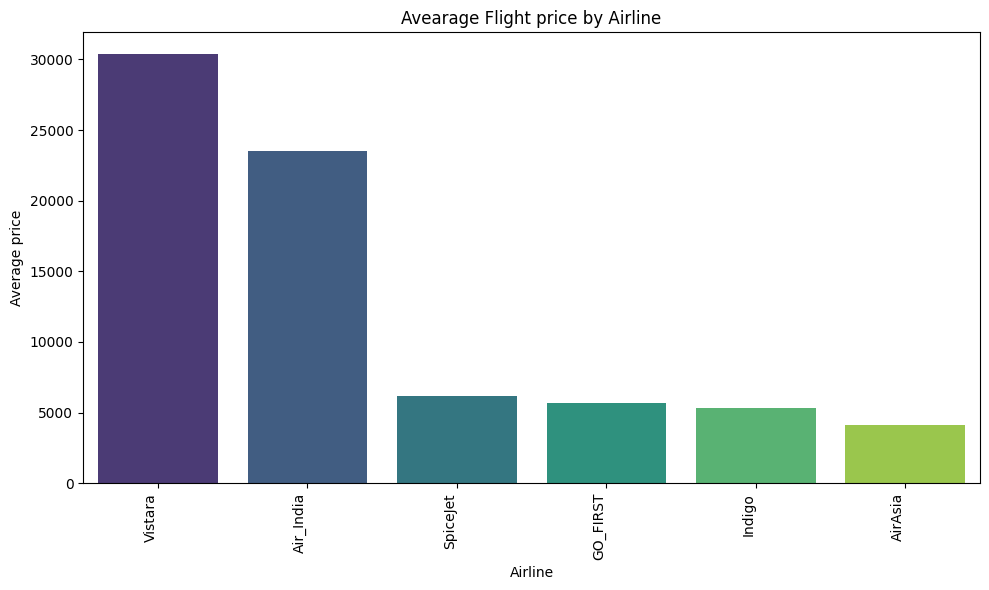

In [10]:
avg_price_by_airline = df.groupby('airline')['price'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(
    x='airline',
    y='price',
    data=avg_price_by_airline,
    palette='viridis'
)
plt.title('Avearage Flight price by Airline')
plt.xlabel('Airline')
plt.ylabel('Average price')
plt.xticks(rotation=90, ha='right')
plt.tight_layout()
plt.show()


C:\Users\Rohan\AppData\Local\Temp\ipykernel_3572\3574188739.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


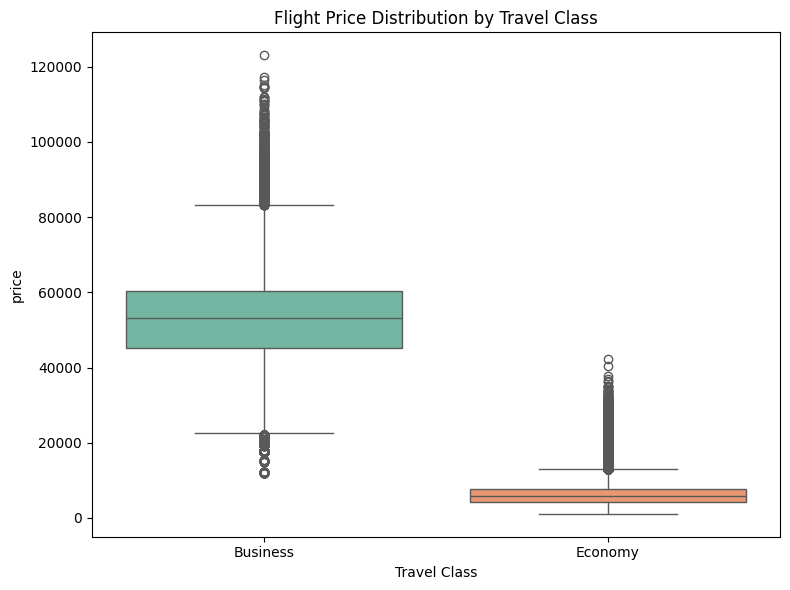

In [11]:
plt.figure(figsize=(8, 6))
sns.boxplot(
    x='class',
    y='price',
    data=df,
    palette='Set2',
    order=['Business', 'Economy'] # order by expected price
)

plt.title('Flight Price Distribution by Travel Class')
plt.xlabel('Travel Class')
plt.ylabel('price')
plt.tight_layout()
plt.show()

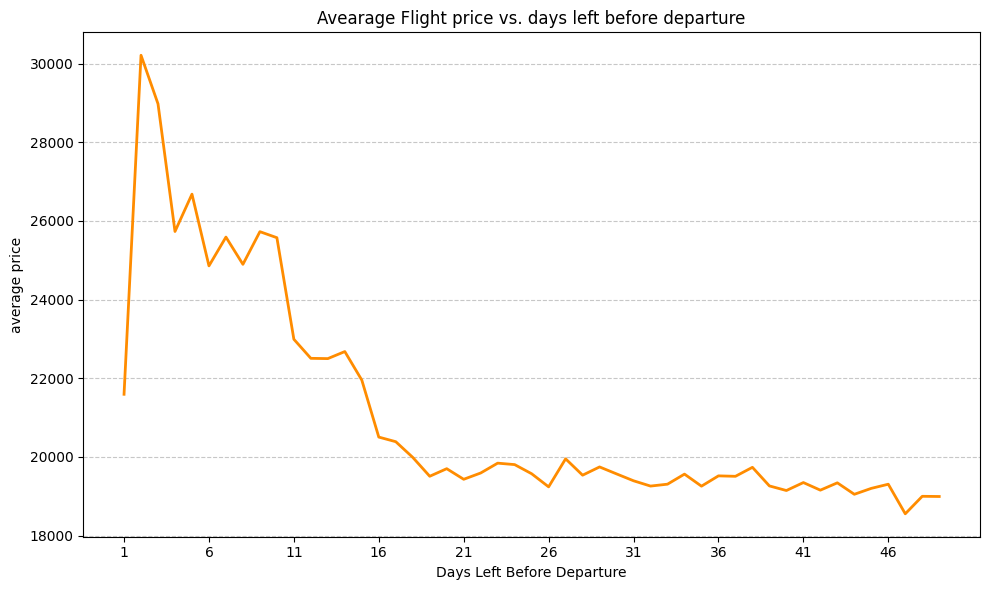

In [12]:
avg_price_by_days_left=df.groupby('days_left')['price'].mean().reset_index()

plt.figure(figsize=(10,6))

sns.lineplot(
    x='days_left',
    y='price',
    data=avg_price_by_days_left,
    color='darkorange',
    linewidth=2
)
plt.title('Avearage Flight price vs. days left before departure')
plt.xlabel('Days Left Before Departure')
plt.ylabel('average price')
plt.xticks(avg_price_by_days_left['days_left'][::5])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()




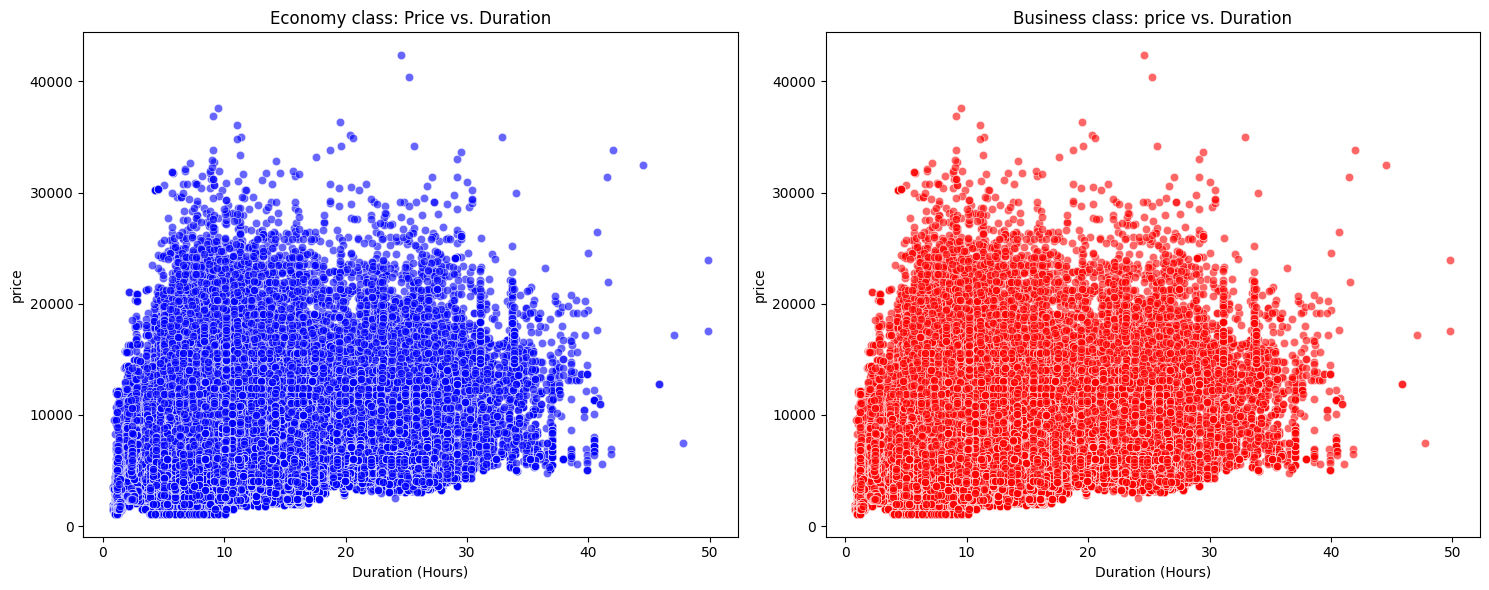

In [13]:
#seperate data by class

economy_df=df[df['class']== 'Economy']
business_df=df[df['class']=='Business']

fig, axes = plt.subplots(1, 2,  figsize=(15, 6))

#Economy class plot

sns.scatterplot( x='duration', y='price', data=economy_df, ax=axes[0], alpha=0.6, color= 'Blue')
axes[0].set_title('Economy class: Price vs. Duration')
axes[0].set_xlabel('Duration (Hours)')
axes[0].set_ylabel('price')

# Business class Plot
sns.scatterplot(x='duration', y='price', data=economy_df, ax=axes[1], alpha=0.6, color='Red')
axes[1].set_title('Business class: price vs. Duration')
axes[1].set_xlabel('Duration (Hours)')
axes[1].set_ylabel('price')

plt.tight_layout()
plt.show()


Data Preprocessing and feature Engineering

1.Handling ordinal Categorial Data(like 'Stops')

Goal: Convert 'Zero'-> 0 and 'One' -> 1

In [14]:
! pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.5/101.7 MB 702.6 kB/s eta 0:02:24
   ---------------------------------------- 0.5/101.7 MB 702.6 kB/s eta 0:02:24
   ---------------------------------------- 1.0/101.7 MB 926.9 kB/s eta 0:01:49
    --------------------------------------- 1.3/101.7 MB 1.1 MB/s eta 0:01:35
    --------------------------------------- 1.8/101.7 MB 1.3 MB/s eta 0:01:18
   - -------------------------------------- 2.6/101.7 MB 1.5 MB/s eta 0:01:04
   - -----------------


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Python314\python.exe -m pip install --upgrade pip


In [15]:
#define the mapping for the 'Stops' column
import pandas as pd
df = pd.read_csv(r"D:\Python Dataset\airlines_flights_data.csv")

stops_mapping ={'zero': 0, 'one':1, 'two_or_more':2}
df['stops_encoded'] = df['stops'].replace(stops_mapping)


C:\Users\Rohan\AppData\Local\Temp\ipykernel_3572\215870388.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['stops_encoded'] = df['stops'].replace(stops_mapping)


In [16]:
print(df)

         index   airline   flight source_city departure_time stops  \
0            0  SpiceJet  SG-8709       Delhi        Evening  zero   
1            1  SpiceJet  SG-8157       Delhi  Early_Morning  zero   
2            2   AirAsia   I5-764       Delhi  Early_Morning  zero   
3            3   Vistara   UK-995       Delhi        Morning  zero   
4            4   Vistara   UK-963       Delhi        Morning  zero   
...        ...       ...      ...         ...            ...   ...   
300148  300148   Vistara   UK-822     Chennai        Morning   one   
300149  300149   Vistara   UK-826     Chennai      Afternoon   one   
300150  300150   Vistara   UK-832     Chennai  Early_Morning   one   
300151  300151   Vistara   UK-828     Chennai  Early_Morning   one   
300152  300152   Vistara   UK-822     Chennai        Morning   one   

         arrival_time destination_city     class  duration  days_left  price  \
0               Night           Mumbai   Economy      2.17          1   5953   

In [17]:
# Drop the original 'stops' column, 'index', and 'flight'
df = df.drop(columns=['index', 'flight', 'stops'])

# Separate features (X) and the target variable (y)
X = df.drop('price', axis=1)
y = df['price']

In [18]:
print(df)

         airline source_city departure_time   arrival_time destination_city  \
0       SpiceJet       Delhi        Evening          Night           Mumbai   
1       SpiceJet       Delhi  Early_Morning        Morning           Mumbai   
2        AirAsia       Delhi  Early_Morning  Early_Morning           Mumbai   
3        Vistara       Delhi        Morning      Afternoon           Mumbai   
4        Vistara       Delhi        Morning        Morning           Mumbai   
...          ...         ...            ...            ...              ...   
300148   Vistara     Chennai        Morning        Evening        Hyderabad   
300149   Vistara     Chennai      Afternoon          Night        Hyderabad   
300150   Vistara     Chennai  Early_Morning          Night        Hyderabad   
300151   Vistara     Chennai  Early_Morning        Evening        Hyderabad   
300152   Vistara     Chennai        Morning        Evening        Hyderabad   

           class  duration  days_left  price  stops

In [19]:
import pandas as pd # Import pandas if not already done

# Identify all remaining categorical columns (object type)
categorical_cols = X.select_dtypes(include='object').columns

# Apply One-Hot Encoding
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

Feature scaling (standarization)

TRANSFORM THE NUMERICAL FEATURES TO HAVE A MEAN ($\mu$) of $0$ and a standard deviation ($\sigma$) of $1$


In [20]:
! pip install scikit-learn
import pandas as pd
from sklearn.preprocessing import StandardScaler

# identify column to scale
cols_to_scale = ['duration', 'days_left']

#Initialize the standardScaler

scalar = StandardScaler()


X_encoded[cols_to_scale] = scalar.fit_transform(X_encoded[cols_to_scale])

Defaulting to user installation because normal site-packages is not writeable
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   ------ --------------------------------- 1.3/8.1 MB 4.1 MB/s eta 0:00:02
   -------------- ------------------------- 2.9/8.1 MB 5.4 MB/s eta 0:00:01
   ---------------------- ----------------- 4.5/8.1 MB 6.0 MB/s eta 0:00:01
   ----------------------------- ---------- 6.0/8.1 MB 6.3 MB/s eta 0:00:01
   ------------------------------------- -- 7.6/8.1 MB 6.5 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 6.5 MB/s  0:00:01
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)

   ------------- -------------------------- 1/3 [joblib]
   -----


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Python314\python.exe -m pip install --upgrade pip


In [21]:
from sklearn.model_selection import train_test_split

#split the data 

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.3,
    random_state=42
)
print(f"Training features shape:{X_train.shape}")
print(f"Testing features shape: {X_test.shape}")


Training features shape:(210107, 29)
Testing features shape: (90046, 29)


Model training and evaluation

In [22]:
import numpy as np

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print(mean_absolute_error)

<function mean_absolute_error at 0x000001FB6AB6FBA0>
